# Offline simulation of ocean biogeochemistry

- salinity is not used for driving the tracer circulation, but is used for checking the bias in the offline tracer circulation.

In [245]:
# Standard imports
import numpy as np
import xarray as xr
import pandas as pd
import os
from numba import njit, prange

# --- IMPORT CUSTOM MODULES ---
# This loads the functions from the .py files
import physics
import biology

# If you edit the .py files while the notebook is running, 
# you need this magic command to auto-reload them:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Define your inputs

## You should not have to modify the rest

In [350]:
# --- 1. CONFIGURATION ---
exp_name = "jcope_nwpac025"
dir_exp = f"../input/{exp_name}"
da_t = xr.open_dataset(f"{dir_exp}/interp_T_01JAN1990.nc")["tm"]
da_s = xr.open_dataset(f"{dir_exp}/interp_S_01JAN1990.nc")["sm"]
da_u = xr.open_dataset(f"{dir_exp}/interp_U_01JAN1990.nc")["um"]
da_v = xr.open_dataset(f"{dir_exp}/interp_V_01JAN1990.nc")["vm"]
da_k = xr.open_dataset(f"{dir_exp}/interp_KH_01JAN1990.nc")["khm"]
da_nswr = xr.open_dataset(f"{dir_exp}/NSWR_01JAN1990.nc")["nswrm"].squeeze()

# Define the climatology file (if you do not have one, use climatology.ipynb to create one)
climatology_file = f"../climatology/{exp_name}/GLODAPv2.2016b.NO3_jcope_nwpac025.nc"
# Restoring timescale (in seconds)
sponge_width = 5
tau_lateral = 5 * 86400.0 
tau_bottom = 60 * 86400.0
# Define the restart file (if set to None, the climatology file will be used for initialization) 
#restart_file = "../output/{exp_name}/output_bgc_19900131_120000.nc" 
restart_file = None


DT_PHYS = 3600.0  # Physics time step (seconds)
steps_per_day = int(86400 / DT_PHYS)

# --- DOMAIN CONFIGURATION ---
# Set the ranges you want to simulate. 
# Use None to include the full range for that dimension.
lat_range   = slice(17, 50)      # Latitude: 20N to 45N
lon_range   = slice(117, 150)    # Longitude: 130E to 180E
depth_range = slice(0, 300)      # Depth: Surface to 500m
time_range  = slice(None, None)  # Time: All steps (or e.g. slice('1990-01-01', '1990-02-01'))

print("Creating a new output directory (if it does not exist)...")
os.makedirs(f"../output/{exp_name}", exist_ok=True)
print("Slicing Model Domain...")
print(f"  Lat: {lat_range}, Lon: {lon_range}, Depth: {depth_range}")

# --- APPLY SLICING ---
# We use .sel() to slice by coordinate values (degrees/meters)
# Note: If your lat/depth are decreasing in the file, xarray handles logic, 
# but double check if you get an empty result.

# 1. Slice Temperature (The Reference Grid)
da_t = da_t.sel(lat=lat_range, lon=lon_range, depth=depth_range, time=time_range)
da_s = da_s.sel(lat=lat_range, lon=lon_range, depth=depth_range, time=time_range)
da_u    = da_u.sel(lat=lat_range, lon=lon_range, depth=depth_range, time=time_range)
da_v    = da_v.sel(lat=lat_range, lon=lon_range, depth=depth_range, time=time_range)
# Surface forcing (NSHF/SW) typically doesn't have depth
da_nswr = da_nswr.sel(lat=lat_range, lon=lon_range, time=time_range) 

# Verify
print(f"  New Grid Shape (T, Z, Y, X): {da_t.shape}")    
# --- 3. MAIN EXECUTION (Robust Setup) ---

# A. Prepare Grid (SAFE MODE)
# Check if coordinates are 2D
if da_t['lat'].ndim == 2:
    print("Detected Curvilinear Grid (2D Lat/Lon).")
    lon_grid = da_t['lon'].values
    lat_grid = da_t['lat'].values
    dx_2d, dy_2d = physics.calculate_metrics_curvilinear(lon_grid, lat_grid)
else:
    print("Detected Rectilinear Grid (1D Lat/Lon).")
    dx_2d, dy_2d = physics.calculate_grid_metrics(da_t)

# B. Calculate DZ
depths = da_t['depth'].values
dz_1d = physics.calculate_dz_from_centers(depths)
temp_ref = da_t.isel(time=0).values 
nz, ny, nx = temp_ref.shape

dz_3d = np.tile(dz_1d[:, np.newaxis, np.newaxis], (1, ny, nx))
water_mask = ~np.isnan(temp_ref)
dz_static = np.where(water_mask, dz_3d, 0.0)

# --- Climatology ---
ds_climatology = xr.open_dataset(climatology_file).squeeze()
# subset based on lon/lat/depth ranges (time is irrelevant for climatology)
ds_climatology = ds_climatology.sel(lat=lat_range, lon=lon_range, depth=depth_range)
no3_climatology = np.nan_to_num(ds_climatology["NO3"].values)
# Create 3D coefficient map for lateral and bottom restoring
nudge_map = physics.create_restoring_weights(water_mask, sponge_width, tau_lateral,
                                     tau_bottom, DT_PHYS)

# --- Initialize offline salinity ---
salt_off = np.nan_to_num(da_s.isel(time=0).values)

# --- INITIALIZE BGC TRACERS ---
if restart_file:
    print(f"RESTART: Loading initial conditions from {restart_file}...")

    # Load the Restart File (squeeze() to get rid of time dimension)
    ds_restart = xr.open_dataset(restart_file).squeeze()
        
    # Map variables to NumPy arrays
    # We apply np.where(water_mask) to ensure land remains perfectly 0.0
    # and fillna(0.0) just in case the file has NaNs.
    no3 = np.where(water_mask, ds_restart['NO3'].fillna(0.0).values, 0.0)
    nh4 = np.where(water_mask, ds_restart['NH4'].fillna(0.0).values, 0.0)
    ps  = np.where(water_mask, ds_restart['PS'].fillna(0.0).values, 0.0)
    pl  = np.where(water_mask, ds_restart['PL'].fillna(0.0).values, 0.0)
    zs  = np.where(water_mask, ds_restart['ZS'].fillna(0.0).values, 0.0)
    zl  = np.where(water_mask, ds_restart['ZL'].fillna(0.0).values, 0.0)
    ds  = np.where(water_mask, ds_restart['DS'].fillna(0.0).values, 0.0)
    dl  = np.where(water_mask, ds_restart['DL'].fillna(0.0).values, 0.0)
    
    # Clean up
    ds_restart.close()
    print("  -> Restart loaded successfully.")

else:
    print("Using the climatology file for initialization...")
    no3 = ds_climatology["NO3"].fillna(0.0).values
    nh4 = np.where(water_mask, 0.01, 0.0)
    ps  = np.copy(nh4)
    pl  = np.copy(nh4)
    zs  = np.copy(nh4)
    zl  = np.copy(nh4)
    ds  = np.copy(nh4)
    dl  = np.copy(nh4)

# List for looping physics easily
tracers = [no3, nh4, ps, pl, zs, zl, ds, dl]

# Create a "Template" DataArray (for saving later)
# We take one slice of temperature to get the Lat/Lon/Depth coords correct
ds_template = da_t.isel(time=0).drop_vars('time')

print("Starting N2P2Z2D2 Simulation...")
nt = da_t['time'].size
# 1. OUTER LOOP: DATA LOADING (Daily)
for day in range(nt):
    print(f"  Day {day+1} / {nt}")
    
    # Load daily inputs (physics)
    t_curr = np.nan_to_num(da_t.isel(time=day).values)
    s_curr = np.nan_to_num(da_s.isel(time=day).values)
    u_curr = np.nan_to_num(da_u.isel(time=day).values)
    v_curr = np.nan_to_num(da_v.isel(time=day).values)
    k_curr = np.nan_to_num(da_k.isel(time=day).values)
    
    # Calculate W (Closed Column)
    w_curr = physics.calculate_w(u_curr, v_curr, dz_static, dx_2d, dy_2d)
    
    # 2. INNER LOOP: PHYSICS & BIO STEPPING (Sub-steps)
    for step in range(steps_per_day):    
        # 1. Physics Loop (Advection/Diffusion)
        # --- Offline salinity ----
        salt_off = physics.advection_neumann(salt_off, u_curr, v_curr, w_curr, dz_static, DT_PHYS, dx_2d, dy_2d)
        salt_off = physics.diffusion_robust(salt_off, k_curr, dz_static, DT_PHYS)
        # Set the uppermost values to equal the online salinity (no freshwater flux in offline)
        salt_off[0,:,:] = s_curr[0,:,:]
        salt_off = np.maximum(salt_off, 0.0)
        # --- BGC tracers ---
        for tr in tracers:
             # Advection
             tr[:] = physics.advection_neumann(tr, u_curr, v_curr, w_curr, dz_static, DT_PHYS, dx_2d, dy_2d)[:]
             # Diffusion
             tr[:] = physics.diffusion_robust(tr, k_curr, dz_static, DT_PHYS)[:]
             # Clean
             tr[:] = np.maximum(tr, 0.0)

        # Unpack updated tracers for Bio
        no3, nh4, ps, pl, zs, zl, ds, dl = tracers
        
        # B. RESTORING (Sponge Layer)
        # ---------------------------
        # Note: nudge_map must be calculated using DT_PHYS
        no3 += (no3_climatology - no3) * nudge_map
        salt_off += (s_curr - salt_off) * nudge_map
        
        # C. BIOLOGY
        # ---------------------
        psum = ps + pl
        par_3d = biology.calculate_par(sw_curr, psum, dz_static)
        
        no3, nh4, ps, pl, zs, zl, ds, dl = biology.biology_n2p2z2d2_numba(
            no3, nh4, ps, pl, zs, zl, ds, dl, 
            t_curr, par_3d, dz_static, DT_PHYS
        )
        
        # D. SINKING
        ds, dl = biology.sinking_dual_numba(ds, dl, dz_static, DT_PHYS)
        
        # 4. Update List (for next physics loop)
        # Important: Python lists hold references, but if biology returns new arrays, 
        # we must update the list references!
        tracers = [no3, nh4, ps, pl, zs, zl, ds, dl]

# ... (Inside the time loop, after biology and sinking) ...

    # 3. Save to Disk (Save All Tracers + PAR)
    # ----------------------------------------
    # Create a mapping of Variable Name -> NumPy Array
    data_map = {
        'NO3': no3,
        'NH4': nh4,
        'PS':  ps,
        'PL':  pl,
        'ZS':  zs,
        'ZL':  zl,
        'DS':  ds,
        'DL':  dl,
        'PAR': par_3d,
        'SALT_OFF': salt_off
    }

    # Initialize an empty Dataset using the template's coordinates
    ds_out = xr.Dataset(coords=ds_template.coords)

    # Loop through and add each variable
    for var_name, data_array in data_map.items():
        ds_out[var_name] = (ds_template.dims, np.where(water_mask,data_array,np.nan))

        # Optional: Add attributes (units, long_name)
        if var_name == 'PAR':
            ds_out[var_name].attrs = {'units': 'W/m^2', 'long_name': 'Photosynthetically Active Radiation'}
        elif var_name == 'SALT_OFF':
            ds_out[var_name].attrs = {'units': 'psu', 'long_name': 'Offline salinity'}        
        elif var_name in ['NO3', 'NH4']:
            ds_out[var_name].attrs = {'units': 'mmol N/m^3', 'long_name': var_name}
        else:
            ds_out[var_name].attrs = {'units': 'mmol N/m^3', 'long_name': f'{var_name} Concentration'}

    # Add Time Dimension
    current_time = da_t.isel(time=day).time.values
    ds_out = ds_out.expand_dims(time=[current_time])
    
    # Generate Filename
    # Use pandas to format the datetime64 object nicely
    time_str = pd.to_datetime(current_time).strftime('%Y%m%d_%H%M%S')
    filename = f"../output/{exp_name}/output_bgc_{time_str}.nc"
    
    # Save to NetCDF
    # encoding={'zlib': True} compresses the file (saves ~60% space)
    comp = dict(zlib=True, complevel=5)
    encoding = {var: comp for var in ds_out.data_vars}
    
    ds_out.to_netcdf(filename, encoding=encoding)
    
    # Clean up memory explicitly (optional but good for long runs)
    ds_out.close()
    
    # Diagnostics
    print(f"    -> NO3:{no3.mean():.2f}")

Creating a new output directory (if it does not exist)...
Slicing Model Domain...
  Lat: slice(17, 50, None), Lon: slice(117, 150, None), Depth: slice(0, 300, None)
  New Grid Shape (T, Z, Y, X): (31, 22, 132, 132)
Detected Rectilinear Grid (1D Lat/Lon).
Using the climatology file for initialization...
Starting N2P2Z2D2 Simulation...
  Day 1 / 31
    -> NO3:2.87
  Day 2 / 31
    -> NO3:2.85
  Day 3 / 31
    -> NO3:2.80
  Day 4 / 31
    -> NO3:2.73
  Day 5 / 31
    -> NO3:2.68
  Day 6 / 31
    -> NO3:2.63
  Day 7 / 31
    -> NO3:2.59
  Day 8 / 31
    -> NO3:2.55
  Day 9 / 31
    -> NO3:2.50
  Day 10 / 31
    -> NO3:2.46
  Day 11 / 31
    -> NO3:2.42
  Day 12 / 31
    -> NO3:2.38
  Day 13 / 31
    -> NO3:2.34
  Day 14 / 31
    -> NO3:2.31
  Day 15 / 31
    -> NO3:2.27
  Day 16 / 31
    -> NO3:2.24
  Day 17 / 31
    -> NO3:2.21
  Day 18 / 31
    -> NO3:2.18
  Day 19 / 31
    -> NO3:2.15
  Day 20 / 31
    -> NO3:2.12
  Day 21 / 31
    -> NO3:2.10
  Day 22 / 31
    -> NO3:2.07
  Day 23 / 31

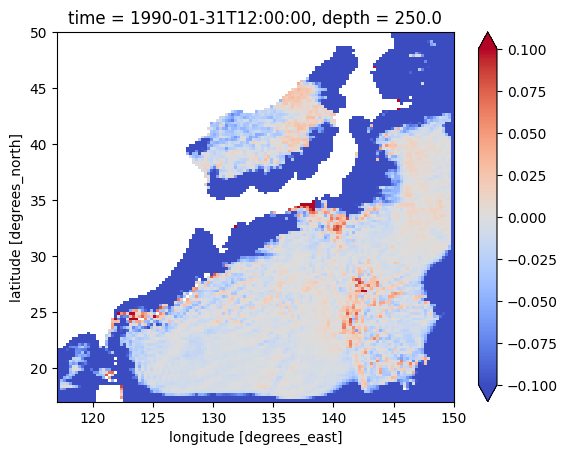

In [351]:
(ds_out["SALT_OFF"][0,20,:,:] - da_s[-1,20,:,:]).plot(vmin=-0.1,vmax=0.1,cmap="coolwarm")

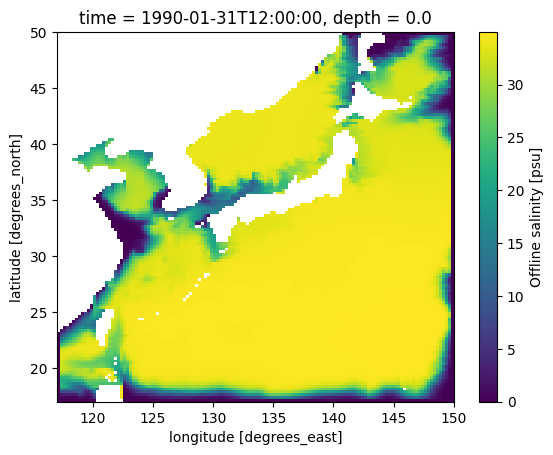

In [336]:
ds_out["SALT_OFF"][0,0,:,:].plot()

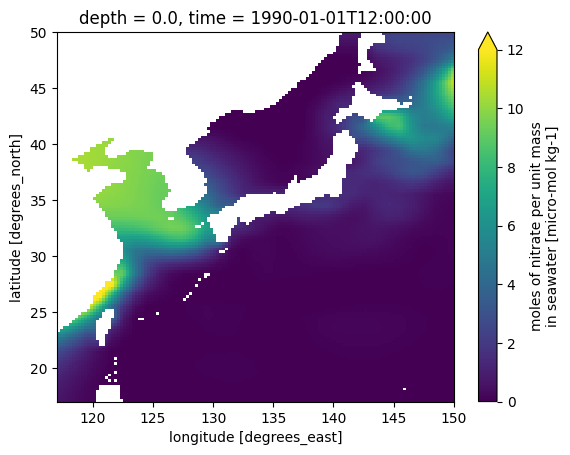

In [326]:
ds_climatology["NO3"][0,:,:].plot(vmin=0,vmax=12)

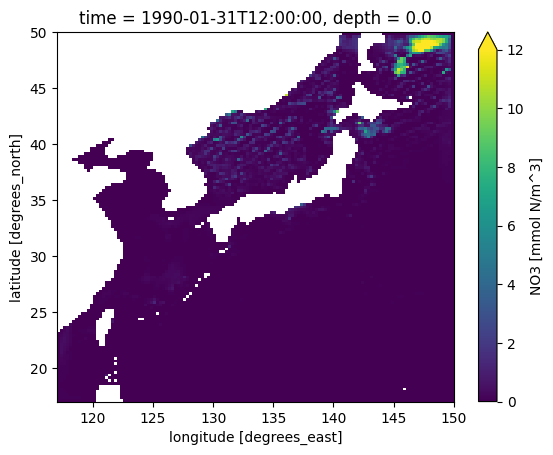

In [325]:
ds_out["NO3"][0,0,:,:].plot(vmin=0,vmax=12)

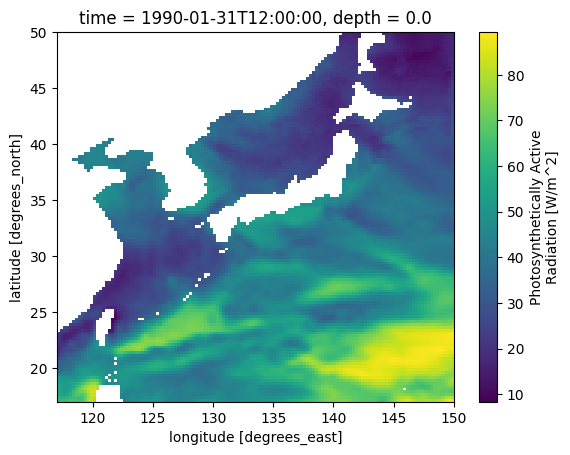

In [329]:
ds_out["PAR"][0,0,:,:].plot()

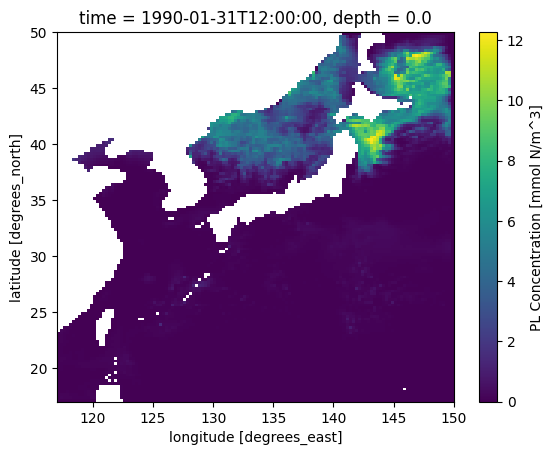

In [333]:
ds_out["PL"][0,0,:,:].plot()

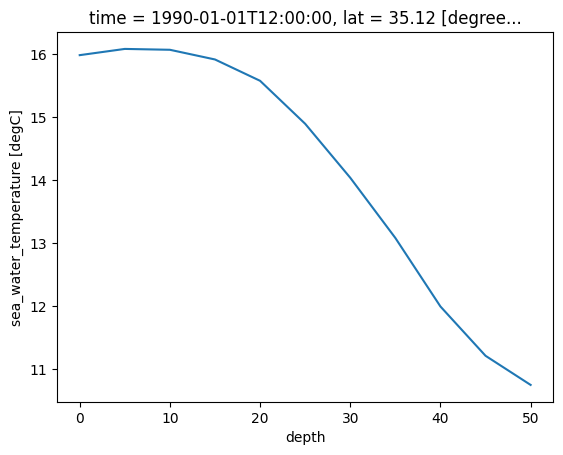

In [330]:
da_t.sel(lat=35,lon=125,method='nearest')[0,:].plot()